# Robot-cell scene builder (Stage 2, Scene 1)

Self-contained, portable scene generator for the device-free worker
**presence + coarse count + coarse zone** task in a **human-robot
collaborative safety cell**.

The real setting: a guarded industrial robot / CNC cell where the
safety question is *is a person inside the robot's reach envelope?*
-- as a pre-start check and a continuous coarse awareness layer.

**Honest framing** (keep in the write-up):
- This is a SIMULATION capability study: does the information live in
  the CSI? It is NOT a product and NOT a certified safety interlock
  (real cells use light curtains / laser scanners; this is a coarse
  complementary layer).
- We do NOT compare against cameras. Motivation for device-free WiFi
  (privacy, obscurants, reuse of existing radios) is cited, not staged.
- The transmitters are the factory's **existing networked equipment**
  (robot controller, tools, conveyor); the AP is a ceiling WiFi AP.
  Nothing new is installed -- we sense using the radios already there.

**How to use**
1. Edit the **PARAMETERS** cell (cell, objects, hazard zone, TX/AP).
2. Run **BUILD** to write the XML + JSON into `robot_cell/`.
3. Run **PREVIEW** to see the top-down layout and adjust.

Pure stdlib + matplotlib (no Sionna, no GPU) -> runs the same on a
laptop, the lab machine, or Colab. This notebook is the single source
of truth for the scene; do not hand-edit a copy elsewhere.

Emits (self-contained, no mesh dir):
- `robot_cell/robot_cell_robot.xml` - robot present (its body self-occludes)
- `robot_cell/robot_cell_norobot.xml` - robot removed (coverage reference)
- `robot_cell/robot_cell.json` - geometry contract for data-gen

Units: metres; +z up; floor surface z=0; cell centred at the origin
(so x in [-X/2, X/2], y in [-Y/2, Y/2]).

In [1]:
# ================================================================
# PARAMETERS  -- edit these, then run BUILD + PREVIEW
# ================================================================

SCENE_NAME = "robot_cell"

# Cell interior (clear inner space)
ROOM_X, ROOM_Y, ROOM_Z = 8.0, 6.0, 4.0
WALL_T = 0.15                 # wall / floor / ceiling thickness

# Sionna maps these strings to ITU radio materials. Valid: concrete,
# brick, plasterboard, wood, glass, metal, ceiling_board, floorboard,
# very_dry_ground, ...
MAT_WALL    = "concrete"      # floor + 4 walls
MAT_CEILING = "metal"         # metal roof deck (industrial)
MAT_METAL   = "metal"         # robot + equipment (metal-heavy, realistic)

# Objects: name, (sx, sy, sz), (cx, cy, cz), material, removable_for_ref
# removable_for_ref objects are dropped from the _norobot.xml variant so
# we can characterise how much the robot's own body degrades sensing of
# a person beside it (coverage reference, NOT a camera comparison).
#
# The robot = pedestal + shoulder + an arm extended over the worktable
# (a fixed static pose; we are snapshot-only).
ROBOT = [
    ("Robot_base",     (0.60, 0.60, 0.70), ( 0.00,  0.00, 0.35), MAT_METAL, True),
    ("Robot_shoulder", (0.45, 0.45, 0.50), ( 0.00,  0.00, 0.95), MAT_METAL, True),
    ("Robot_arm",      (1.00, 0.30, 0.30), ( 0.65,  0.00, 1.25), MAT_METAL, True),
]
# Fixed cell equipment (kept in BOTH variants).
EQUIPMENT = [
    ("Worktable",   (1.20, 0.80, 0.90), ( 1.50,  0.00, 0.45), MAT_METAL, False),
    ("Cabinet",     (0.80, 0.60, 1.80), (-3.20, -2.20, 0.90), MAT_METAL, False),
    ("Conveyor",    (2.50, 0.60, 0.60), ( 0.00, -2.40, 0.30), MAT_METAL, False),
    ("Guard_panel", (0.10, 2.00, 1.20), (-1.80,  1.40, 0.60), MAT_METAL, False),
]
OBJECTS = ROBOT + EQUIPMENT

# Hazard zone = the robot's REACH ENVELOPE (a floor rectangle around the
# base + worktable). A worker footprint inside it -> label 'in zone'.
# Metadata, NOT a physical shape.
HAZARD_ZONE = {"type": "rect",
               "x_min": -1.6, "x_max": 2.4,
               "y_min": -1.8, "y_max": 1.8}

# Worker placement region: floor inset from walls, minus object
# footprints (+ clearance). Data-gen samples worker (x,y) here and
# rejects points inside any exclusion rect.
WORKER_INSET = 0.5       # keep workers this far off the walls
OBJ_CLEARANCE = 0.3      # keep workers this far from object footprints

# TX = the factory's EXISTING networked equipment (antenna just outside
# each host's surface). AP = a ceiling WiFi AP. NOT written into the XML
# (added later in the data-gen script); positions live in the sidecar.
SUGGESTED_TX = [
    ("iot_cabinet",  (-3.20, -2.20, 1.85)),   # on the robot controller cabinet
    ("iot_table",    ( 2.00,  0.45, 1.00)),   # networked tool on the worktable
    ("iot_conveyor", ( 1.20, -2.40, 0.65)),   # sensor on the parts conveyor
    ("iot_eastwall", ( 3.85,  1.50, 2.20)),   # wall-mounted networked device
]
SUGGESTED_AP = {"pos": (2.00, 1.50, 3.90), "n_ant": 4}   # ceiling AP

print("parameters loaded:", SCENE_NAME,
      f"| cell {ROOM_X}x{ROOM_Y}x{ROOM_Z} m | {len(OBJECTS)} objects")

parameters loaded: robot_cell | cell 8.0x6.0x4.0 m | 7 objects


In [2]:
# ================================================================
# GENERATOR  -- Mitsuba-3 XML + sidecar. No need to edit.
# ================================================================
import json
from pathlib import Path


def room_boxes():
    hx, hy, hz = ROOM_X / 2, ROOM_Y / 2, ROOM_Z / 2
    t = WALL_T
    return [
        ("Floor",   (ROOM_X, ROOM_Y, t), (0.0, 0.0, -t / 2),         MAT_WALL),
        ("Ceiling", (ROOM_X, ROOM_Y, t), (0.0, 0.0, ROOM_Z + t / 2), MAT_CEILING),
        ("Wall_N",  (ROOM_X, t, ROOM_Z), (0.0,  hy + t / 2, hz),     MAT_WALL),
        ("Wall_S",  (ROOM_X, t, ROOM_Z), (0.0, -hy - t / 2, hz),     MAT_WALL),
        ("Wall_E",  (t, ROOM_Y, ROOM_Z), ( hx + t / 2, 0.0, hz),     MAT_WALL),
        ("Wall_W",  (t, ROOM_Y, ROOM_Z), (-hx - t / 2, 0.0, hz),     MAT_WALL),
    ]


def bsdf_xml(mat_type):
    return (f'    <bsdf type="itu-radio-material" id="mat-{mat_type}">\n'
            f'        <string name="type" value="{mat_type}"/>\n'
            f'    </bsdf>\n')


def cube_xml(name, size, center, mat_type):
    # Mitsuba `cube` is the unit cube [-1,1]^3 (half-extent 1):
    # scale by half-extents, then translate to the centre.
    hx, hy, hz = size[0] / 2, size[1] / 2, size[2] / 2
    cx, cy, cz = center
    return (f'    <shape type="cube" id="{name}">\n'
            f'        <transform name="to_world">\n'
            f'            <scale x="{hx:.4f}" y="{hy:.4f}" z="{hz:.4f}"/>\n'
            f'            <translate x="{cx:.4f}" y="{cy:.4f}" z="{cz:.4f}"/>\n'
            f'        </transform>\n'
            f'        <ref id="mat-{mat_type}"/>\n'
            f'    </shape>\n')


def build_scene_xml(include_robot):
    boxes = [(n, s, c, m) for (n, s, c, m) in room_boxes()]
    for (n, s, c, m, removable) in OBJECTS:
        if removable and not include_robot:
            continue
        boxes.append((n, s, c, m))
    used = sorted({mat for (_, _, _, mat) in boxes})
    parts = ['<scene version="3.0.0">\n', '    <integrator type="path"/>\n\n']
    parts += [bsdf_xml(m) for m in used]
    parts.append('\n')
    parts += [cube_xml(n, s, c, m) for (n, s, c, m) in boxes]
    parts.append('</scene>\n')
    return "".join(parts)


def _footprint(size, center, clearance):
    hx, hy = size[0] / 2 + clearance, size[1] / 2 + clearance
    cx, cy = center[0], center[1]
    return {"x_min": cx - hx, "x_max": cx + hx,
            "y_min": cy - hy, "y_max": cy + hy}


def build_sidecar():
    exclusions = [{"name": n, **_footprint(s, c, OBJ_CLEARANCE)}
                  for (n, s, c, m, _r) in OBJECTS]
    return {
        "scene_name": SCENE_NAME,
        "scenario": "human-robot collaborative safety cell",
        "units": "metres; +z up; floor z=0; cell centred at origin",
        "room": {"x": ROOM_X, "y": ROOM_Y, "z": ROOM_Z, "wall_t": WALL_T},
        "materials": {"wall": MAT_WALL, "ceiling": MAT_CEILING,
                      "equipment": MAT_METAL},
        "objects": [{"name": n, "size": list(s), "center": list(c),
                     "material": m, "removable_for_ref": r}
                    for (n, s, c, m, r) in OBJECTS],
        "robot_objects": [n for (n, _, _, _, r) in OBJECTS if r],
        "hazard_zone": HAZARD_ZONE,
        "hazard_zone_meaning": "robot reach envelope",
        "worker_region": {
            "type": "rect_with_exclusions",
            "x_min": -ROOM_X / 2 + WORKER_INSET,
            "x_max":  ROOM_X / 2 - WORKER_INSET,
            "y_min": -ROOM_Y / 2 + WORKER_INSET,
            "y_max":  ROOM_Y / 2 - WORKER_INSET,
            "exclusions": exclusions,
        },
        "suggested_tx": [{"name": n, "pos": list(p), "host": n.replace('iot_', '')}
                         for (n, p) in SUGGESTED_TX],
        "suggested_ap": {"pos": list(SUGGESTED_AP["pos"]),
                         "n_ant": SUGGESTED_AP["n_ant"], "mount": "ceiling"},
        "variants": {"robot": f"{SCENE_NAME}_robot.xml",
                     "norobot": f"{SCENE_NAME}_norobot.xml"},
    }

print("generator ready")

generator ready


In [3]:
# ================================================================
# BUILD  -- write the two XMLs + JSON sidecar
# ================================================================
# Output next to this notebook (works on any PC). On Colab, if the
# notebook dir is read-only, this falls back to the current dir.
try:
    base_dir = Path(__file__).parent  # not defined in notebooks
except NameError:
    base_dir = Path.cwd()

out_dir = base_dir / SCENE_NAME
out_dir.mkdir(parents=True, exist_ok=True)

robot_path = out_dir / f"{SCENE_NAME}_robot.xml"
noro_path = out_dir / f"{SCENE_NAME}_norobot.xml"
json_path = out_dir / f"{SCENE_NAME}.json"

robot_path.write_text(build_scene_xml(include_robot=True), encoding="utf-8")
noro_path.write_text(build_scene_xml(include_robot=False), encoding="utf-8")
json_path.write_text(json.dumps(build_sidecar(), indent=2), encoding="utf-8")

print("wrote:")
print(" ", robot_path)
print(" ", noro_path)
print(" ", json_path)
print(f"  robot   : 6 shell + {len(ROBOT)} robot + {len(EQUIPMENT)} equipment")
print(f"  norobot : 6 shell + {len(EQUIPMENT)} equipment (robot removed)")

wrote:
  d:\91\Post Graduate\Project selection\Wireless Sensing\workspace\stage2\scenes\robot_cell\robot_cell_robot.xml
  d:\91\Post Graduate\Project selection\Wireless Sensing\workspace\stage2\scenes\robot_cell\robot_cell_norobot.xml
  d:\91\Post Graduate\Project selection\Wireless Sensing\workspace\stage2\scenes\robot_cell\robot_cell.json
  robot   : 6 shell + 3 robot + 4 equipment
  norobot : 6 shell + 4 equipment (robot removed)


## Preview (top-down)

Eyeball the layout and adjust the PARAMETERS cell. Metal objects are
grey (robot hatched = removed in the no-robot reference variant), the
hazard zone (robot reach) is the red square, faint red boxes are the
excluded object footprints (no worker sampled there), the dashed
rectangle is the legal worker region, triangles are the equipment-
mounted TXs, the square is the ceiling AP.

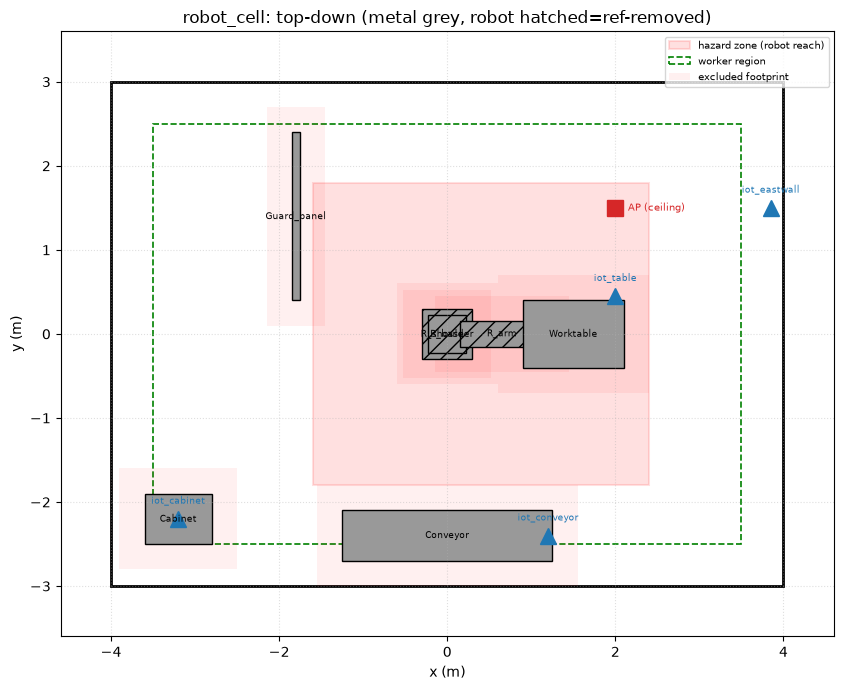

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

cfg = build_sidecar()
fig, ax = plt.subplots(figsize=(9, 7))

# room interior
hx, hy = ROOM_X / 2, ROOM_Y / 2
ax.add_patch(Rectangle((-hx, -hy), ROOM_X, ROOM_Y, fill=False,
                       edgecolor="black", lw=2))

# hazard zone (robot reach)
hz = cfg["hazard_zone"]
ax.add_patch(Rectangle((hz["x_min"], hz["y_min"]),
                       hz["x_max"] - hz["x_min"], hz["y_max"] - hz["y_min"],
                       facecolor="red", alpha=0.12, edgecolor="red",
                       lw=1.5, label="hazard zone (robot reach)"))

# worker-placement region (legal sampling area)
wr = cfg["worker_region"]
ax.add_patch(Rectangle((wr["x_min"], wr["y_min"]),
                       wr["x_max"] - wr["x_min"], wr["y_max"] - wr["y_min"],
                       fill=False, edgecolor="green", ls="--", lw=1.2,
                       label="worker region"))

# excluded object footprints (no worker sampled here)
for i, ex in enumerate(wr["exclusions"]):
    ax.add_patch(Rectangle((ex["x_min"], ex["y_min"]),
                           ex["x_max"] - ex["x_min"], ex["y_max"] - ex["y_min"],
                           facecolor="red", alpha=0.06, edgecolor="none",
                           label="excluded footprint" if i == 0 else None))

# objects (footprints), robot hatched (removed in reference variant)
for o in cfg["objects"]:
    sx, sy = o["size"][0], o["size"][1]
    cxx, cyy = o["center"][0], o["center"][1]
    hatch = "//" if o["removable_for_ref"] else None
    ax.add_patch(Rectangle((cxx - sx / 2, cyy - sy / 2), sx, sy,
                           facecolor="0.6", edgecolor="black",
                           hatch=hatch, lw=1.0))
    ax.text(cxx, cyy, o["name"].replace("Robot_", "R_"),
            ha="center", va="center", fontsize=6.5)

# TXs on equipment + ceiling AP
for t in cfg["suggested_tx"]:
    ax.plot(t["pos"][0], t["pos"][1], "^", color="tab:blue", ms=11)
    ax.text(t["pos"][0], t["pos"][1] + 0.18, t["name"],
            ha="center", fontsize=6.5, color="tab:blue")
ap = cfg["suggested_ap"]["pos"]
ax.plot(ap[0], ap[1], "s", color="tab:red", ms=12)
ax.text(ap[0] + 0.15, ap[1], "AP (ceiling)", va="center", fontsize=7.5,
        color="tab:red")

ax.set_xlim(-hx - 0.6, hx + 0.6)
ax.set_ylim(-hy - 0.6, hy + 0.6)
ax.set_aspect("equal")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title(f"{SCENE_NAME}: top-down (metal grey, robot hatched=ref-removed)")
ax.legend(loc="upper right", fontsize=7.5)
ax.grid(True, ls=":", alpha=0.4)
plt.tight_layout()
plt.show()